# Color correction using a reference color card
 
In this tutorial we'll go over how to adjust the color of an image using the `ColorCorrection` class.


In [1]:
# Session details:
import traitly
from datetime import datetime

print(f"Traitly version used in this tutorial: {traitly.__version__}")
print(f"Run date: {datetime.now():%Y-%m-%d %H:%M}") 

Traitly version used in this tutorial: 0.2.0
Run date: 2026-10-05 21:31


 
Starting with version 0.2.0, Traitly includes a new class for correcting the color of an image when you have a 24-patch color card in the picture. This process is independent of the `FruitInternalAnalyzer` and `FruitExternalAnalyzer` classes, so you can correct images that don't include any fruit, as long as the card is visible. That said, we kept the logic and method names consistent across the three classes, for reproducibility and clarity.

The first step is to import the main class and load the image we want to analyze with `load_image()`.
 

In [1]:
from traitly.color_correction import ColorCorrection

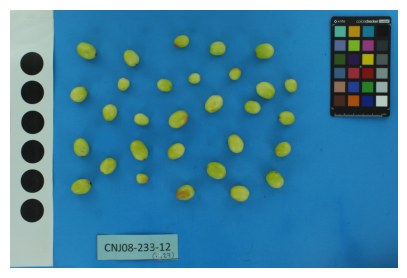

In [2]:
path = "/Users/alejandra/Documents/traitly-tutorials/color_correction/cnj0823312.jpg"

cc = ColorCorrection(path)
cc.load_image()

Next, we detect the color card in the image with `detect_color_checker()`. For this step, the background and the content of the image don't matter, as long as there is a 24-patch Macbeth card in it. Detection doesn't depend on orientation, and the card can even be slightly tilted, although for best results it's recommended that the card is as sharp and clear as possible. If there are several cards in the same image, for now only one is used: the first one OpenCV detects.

Once the card is detected, the mean color of each patch is extracted and stored internally in the LAB color space.


★ COLOR CARD:
> Color checker detected: 
    - Coordinates: x1=4299, y1=190, x2=5088, y2=1331


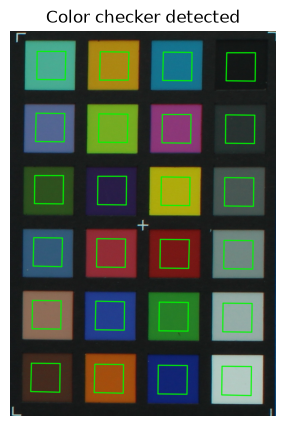

In [3]:
cc.detect_color_checker(plot = True)

Now we apply the correction with `apply_color_correction()`. The goal is to adjust the detected colors of the 24 patches to the card's LAB D65 reference values (derived from X-Rite's data). To do this, the detected L, a and b values are expanded into polynomial terms (including their interactions), and with those we fit a partial least squares regression (PLSR) model for each of the L, a and b channels. This way, lightness (L) and chroma (a and b) are corrected by separate models. The degree of the polynomial is set with `degree`.
 
The higher the degree, the more terms the model has, so we can capture more complex interactions. However, with only 24 patches there is also a risk of overfitting. That's why `apply_color_correction()` lets you set the number of PLSR components to use, through the `num_components` argument.
 
Fitting the models is fast, but applying the correction to every pixel in the image can take a few seconds. Once it finishes, the results are displayed, where you can see the original and the corrected image. In this example, our original image is a bit dark and the fruits look slightly green. After correction, the fruits look warmer and more realistic, and the whites are adjusted, as you can see in the white of the circle strip and in the white patch of the color card.

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Correcting color, this may take a few seconds... ⋆✧｡٩(ˊᗜˋ)و✧*｡


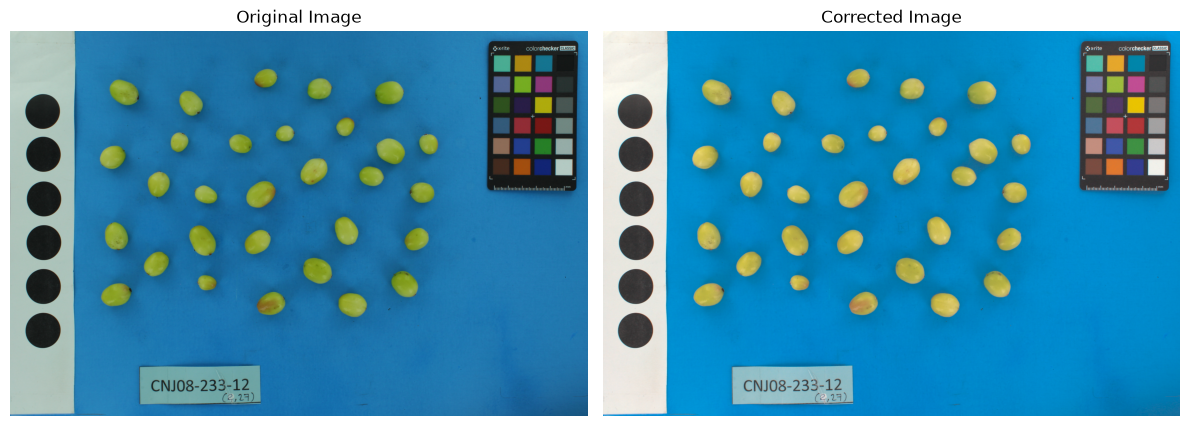

Correction finished!


In [7]:
cc.apply_color_correction(degree = 3, 
                          num_components = 11, 
                          plot_size = (12,12))

That said, it's important to remember that the colors we see depend on our screen, so we can't tell how good the correction was from a visual inspection alone. For this we can calculate delta E (2000), a metric that compares two colors in the LAB color space. In other words, it gives us an idea of how different each patch is from the reference before (delta E before) and after (delta E after) the correction. To calculate it we use the `calculate_delta_e_stats()` method, which displays a table with the results and some summary statistics: the mean value across patches before and after the correction, as well as the improvement for each patch.
 
In general, a delta E of 0 means the colors are identical, and a value below 1 is barely perceptible to the human eye. Between 1 and 2 the difference is only noticeable on close inspection, between 2 and 4 the differences are subtle and depend on the sharpness of the viewer's eye, and above 4 the colors are considered different. According to the results, the correction brought the patch colors closer to the reference, lowering the mean delta E from 12.04 to 1.59. Keep in mind that this value is calculated on the same patches the model was fitted on.

In [8]:
cc.calculate_delta_e_stats(verbose = True)

-------------------------------------------------------
Mean ΔE before: 12.04
Mean ΔE after: 1.59
-------------------------------------------------------
Patch             | ΔE before | ΔE after | Diff
-------------------------------------------------------
A1: dark skin     |     13.45 |     3.27 |  10.18
B1: light skin    |     16.07 |     0.59 |  15.49
C1: blue sky      |     12.07 |     2.97 |   9.10
D1: foliage       |     11.62 |     1.83 |   9.79
E1: blue flower   |     13.54 |     2.91 |  10.63
F1: bluish green  |      6.03 |     1.20 |   4.83
A2: orange        |     18.97 |     1.39 |  17.58
B2: purplish blue |      9.34 |     0.77 |   8.57
C2: moderate red  |     14.76 |     0.78 |  13.99
D2: purple        |     12.63 |     2.84 |   9.79
E2: yellow green  |      6.81 |     0.41 |   6.41
F2: orange yellow |     12.48 |     1.73 |  10.74
A3: blue          |      7.99 |     1.98 |   6.00
B3: green         |      8.02 |     0.85 |   7.17
C3: red           |     13.74 |     0.39 |

Finally, we can save the corrected image and the parameters used in the session, so we can reuse them if we want to analyze multiple images with `analyze_folder()`.

In [5]:
cc.save_img()
cc.save_parameters()


– Image saved at: /Users/alejandra/Documents/traitly-tutorials/color_correction/d65_corrected.png


In the previous example we used an underexposed image. Now let's see what happens in the opposite case.


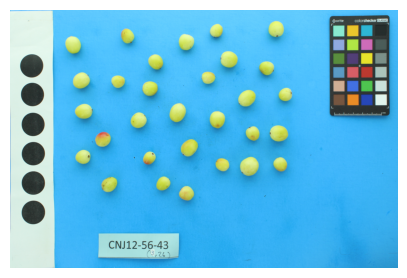


★ COLOR CARD:
> Color checker detected: 
    - Coordinates: x1=4292, y1=175, x2=5063, y2=1313


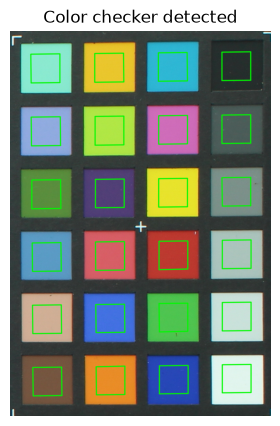

In [6]:
path = "/Users/alejandra/Documents/traitly-tutorials/color_correction/cnj125643.jpg"
cc = ColorCorrection(path)
cc.load_image()
cc.detect_color_checker(plot = True)

Just like in the previous example, the colors look visibly more natural, and the brightness of both corrected images is now comparable. This is especially useful when comparing images taken under different lighting, which could otherwise bias the color results.

Correcting color, this may take a few seconds... ⋆✧｡٩(ˊᗜˋ)و✧*｡


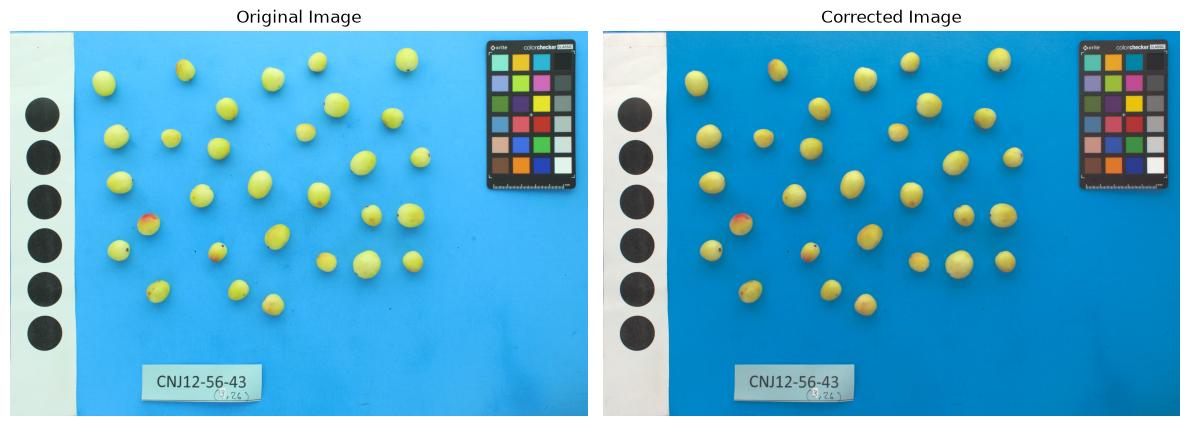

Correction finished!


In [7]:
cc.apply_color_correction(degree = 3, 
                          num_components = 11, 
                          plot_size = (12,12))

In [8]:
cc.calculate_delta_e_stats(verbose = True)

-------------------------------------------------------
Mean ΔE before: 10.01
Mean ΔE after: 1.29
-------------------------------------------------------
Patch             | ΔE before | ΔE after | Diff
-------------------------------------------------------
A1: dark skin     |      4.81 |     0.94 |   3.88
B1: light skin    |     10.93 |     1.16 |   9.76
C1: blue sky      |     13.14 |     2.61 |  10.53
D1: foliage       |     13.46 |     0.89 |  12.57
E1: blue flower   |     15.63 |     2.10 |  13.53
F1: bluish green  |     11.28 |     0.78 |  10.50
A2: orange        |      6.61 |     1.23 |   5.38
B2: purplish blue |     11.05 |     1.56 |   9.48
C2: moderate red  |      5.79 |     0.50 |   5.29
D2: purple        |      6.08 |     0.49 |   5.59
E2: yellow green  |     10.57 |     0.12 |  10.45
F2: orange yellow |     12.56 |     1.03 |  11.53
A3: blue          |      5.70 |     0.81 |   4.89
B3: green         |     14.87 |     0.74 |  14.13
C3: red           |      4.53 |     0.12 |

Our correction is designed (for now) for images taken under controlled lighting, like the ones expected in `FruitInternalAnalyzer` and `FruitExternalAnalyzer`. However, it's also possible to correct images from other contexts or taken outdoors. The main condition for it to work well is that the brightness of the color card is similar to the brightness of the rest of the image. This is needed because the model adjusts the LAB values based only on the card, and then applies that same transformation to every pixel in the image equally.
 
So, if the card is very dark and the background very bright, or vice versa, we can get poor results, as in the following image. In the corrected image, the colors of the card look good and the mean delta E is below 3, which is good. But the rest of the image looks overexposed. This happens because when the brightness of the card was increased, the brightness of the rest of the image was increased by the same amount. Note that delta E only evaluates the patches, which is why it doesn't catch this problem.
 
We're still working on the `ColorCorrection` class, so we hope to include models better suited to this kind of situation soon.

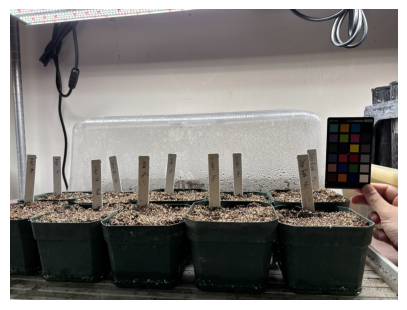


★ COLOR CARD:
> Color checker detected: 
    - Coordinates: x1=4698, y1=1661, x2=5318, y2=2575


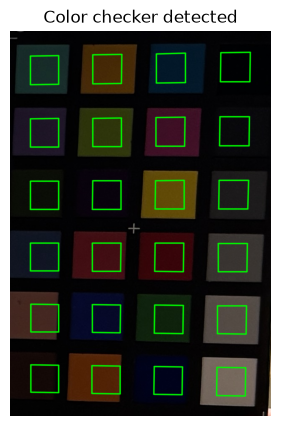

Correcting color, this may take a few seconds... ⋆✧｡٩(ˊᗜˋ)و✧*｡


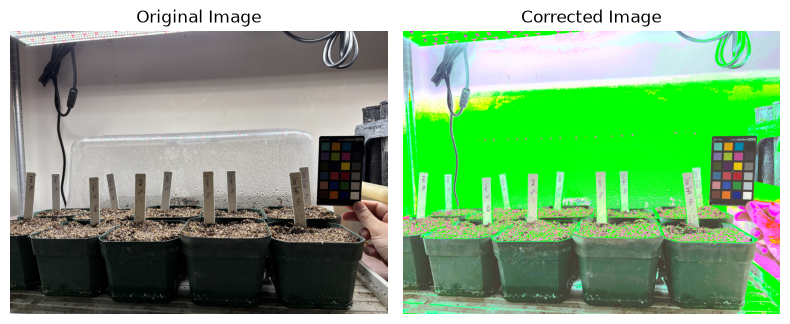

Correction finished!
-------------------------------------------------------
Mean ΔE before: 35.22
Mean ΔE after: 2.98
-------------------------------------------------------
Patch             | ΔE before | ΔE after | Diff
-------------------------------------------------------
A1: dark skin     |     26.99 |     2.89 |  24.10
B1: light skin    |     41.82 |     7.72 |  34.10
C1: blue sky      |     33.41 |     3.49 |  29.92
D1: foliage       |     32.38 |     5.51 |  26.88
E1: blue flower   |     37.78 |     3.70 |  34.08
F1: bluish green  |     52.00 |     1.06 |  50.94
A2: orange        |     39.04 |     1.10 |  37.94
B2: purplish blue |     27.81 |     1.08 |  26.73
C2: moderate red  |     30.74 |     2.08 |  28.65
D2: purple        |     25.41 |     4.01 |  21.40
E2: yellow green  |     50.72 |     0.80 |  49.92
F2: orange yellow |     50.63 |     2.09 |  48.54
A3: blue          |     23.56 |     1.88 |  21.69
B3: green         |     37.40 |     0.52 |  36.88
C3: red           |  

In [9]:
cc = ColorCorrection("/Users/alejandra/Documents/traitly-tutorials/color_correction/IMG_6859.JPG")
cc.load_image()
cc.detect_color_checker(plot = True)
cc.apply_color_correction(plot = True)
cc.calculate_delta_e_stats(verbose = True)
